# Adaptive Gradient Boosting (AGB) Explained

Pega's **Adaptive Decision Manager (ADM)** uses **Adaptive Gradient Boosting
(AGB)** as its default predictive algorithm for Next-Best-Action recommendations.
AGB is an online-learning variant of gradient boosted trees that continuously
updates as new customer interactions arrive — no batch retraining required.

**Pega documentation:**
- [Adaptive Gradient boosting overview](https://docs.pega.com/bundle/alerts/page/platform/decision-management/adaptive-boosting-algorithm.html) — what AGB is and why it replaces Naïve Bayes
- [The Gradient boosting technique](https://docs.pega.com/bundle/alerts/page/platform/decision-management/adaptive-gradient-boosting.html) — deep dive: ensemble construction, gain formula, ADWIN pruning
- [Downloading a Gradient boosting Adaptive Model](https://docs.pega.com/bundle/alerts/page/platform/decision-management/gradient-boosting-model.html) — how to export the JSON from Prediction Studio
- [Interpreting Gradient boosting predictor importance](https://docs.pega.com/bundle/alerts/page/platform/decision-management/gradient-boosting-explanations.html) — reading the feature importance analysis in Prediction Studio

This notebook explains:

1. [**How a single decision tree works**](#1.-The-Building-Block:-A-Single-Decision-Tree) — nodes, splits, and the gain formula.
2. [**How trees combine**](#2.-The-Ensemble:-How-Trees-Build-on-Each-Other) into an ensemble, how the model grows over time, and
   the cold-start / warm-start behaviour.
3. [**How a customer is scored**](#3.-Scoring-a-Customer) — tracing the path through every tree.
4. [**Which predictors matter**](#4.-Feature-Importance:-Which-Predictors-Drive-the-Model?) — feature importance from split gains.
5. [**How to read model health**](#5.-Model-Health-at-a-Glance) — key metrics and what they signal.
6. [**Model AUC and calibration**](#6.-Model-AUC-and-Calibration) — how the model is evaluated and what the AUC score means.

All examples use the `pdstools` sample AGB model.


> **📦 Optional dependencies**
>
> This article uses the `pdstools` `adm` extra, and requires `pydot` and
> `graphviz` for tree visualizations. Install with your favorite package
> manager, e.g. `uv pip install "pdstools[adm]" pydot graphviz`.


In [1]:
# These lines are only for rendering in the docs, and are hidden through Jupyter tags
# Do not run if you're running the notebook separately

import plotly.io as pio

pio.renderers.default = "notebook_connected"


In [2]:
import json
import polars as pl
from math import exp
from great_tables import GT
from pdstools import datasets

AGBModel = datasets.sample_trees()
# To use your own model, export the JSON from Prediction Studio and load it with:
# from pdstools.adm.trees import ADMTreesModel
# AGBModel = ADMTreesModel.from_file("path/to/model_export.json")
# See: https://docs.pega.com/bundle/platform/page/platform/pega-ai-tools/export-model-data-prediction-studio.html
print(f"Loaded model: {len(AGBModel.model)} trees, Pooled AUC={AGBModel.metrics['auc']:.4f}")
print(f"Training data: {AGBModel.metrics['response_positive_count']:,} positives, "
      f"{AGBModel.metrics['response_negative_count']:,} negatives")

Loaded model: 83 trees, Pooled AUC=0.8098
Training data: 56,182 positives, 10,631,119 negatives


**Caveat:** Pooled AUC—computed by mixing prediction scores and outcomes across all actions before drawing a single ROC curve—is systematically inflated by action base-rate differences and action-mix. It is therefore not a reliable measure of the discriminative power of any individual action model. For model-performance assessment, prefer the response-count weighted average of per-action AUC values, explained in **Pooled vs weighted-average AUC** below.

## 1. The Building Block: A Single Decision Tree

AGB is an **ensemble** of binary decision trees. Each tree is a directed graph
where internal nodes split the population by a predictor threshold and leaf
nodes hold a **score** (a real number in log-odds space).

The model JSON stores each tree as a nested dict. Here is the root node of
the first tree:


In [3]:
# Show the root node of tree 0 — the first split the model makes
root = AGBModel.model[0]
print(json.dumps(
    {k: v for k, v in root.items() if k not in ("left", "right")},
    indent=2,
))


{
  "score": -0.19775,
  "gain": 1597.41854,
  "sampleCount": 15052537,
  "split": "pyTreatment in { Action_01 }"
}


Each node contains:

| Field | Meaning |
|---|---|
| `split` | The branching condition (`predictor op threshold`). |
| `gain` | How much this split reduces prediction error (see formula below). |
| `score` | The log-odds leaf score assigned to customers reaching this node. |
| `sampleCount` | Number of training responses routed through this node. |
| `left` / `right` | Child sub-trees (condition true → left, false → right). |

### The Split Gain Formula

AGB uses the XGBoost-style **gradient-based split gain**. For a candidate
split that partitions the training responses into left ($L$) and right ($R$)
groups:

$$
\text{Gain} = \frac{1}{2}\left[
  \frac{G_L^2}{H_L + \lambda} +
  \frac{G_R^2}{H_R + \lambda} -
  \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}
\right] - \gamma
$$

Where:
- $G = \sum g_i$ with $g_i = p_i - y_i$ — the **prediction error**
  (residual) of the current model for response $i$.
- $H = \sum h_i$ with $h_i = p_i(1 - p_i)$ — the **Hessian** (curvature).
- $\lambda$ — L2 regularisation on leaf scores.
- $\gamma$ — the **complexity threshold**: a split is only created when
  Gain $> 0$ after subtracting $\gamma$. This prevents over-splitting.

A split is only added to the tree if this gain is positive.  High gain at
the root means the split strongly separates positives from negatives.

**ADWIN — the adaptation mechanism:** Each node continuously monitors its
prediction error using an Adaptive Sliding Window (ADWIN).  When the error
rises — signalling concept drift — the window shrinks and the effective gain
falls. Branches whose gain drops below $\gamma$ are **pruned**, allowing the
model to forget stale patterns and grow fresh splits.


In [4]:
# Predictors used by this model, by type
print(f"Total predictors: {len(AGBModel.predictors)}")
for ptype in ["symbolic", "numeric"]:
    names = [k for k, v in AGBModel.predictors.items() if v == ptype]
    print(f"  {ptype}: {len(names)} — e.g. {names[:3]}")


Total predictors: 194
  symbolic: 28 — e.g. ['pyTreatment', 'pyName', 'pyGroup']
  numeric: 166 — e.g. ['Customer.Attr01', 'IH.Mobile.Inbound.Clicked.pxLastOutcomeTime.DaysSince', 'IH.Mobile.Inbound.Rejected.pyHistoricalOutcomeCount']


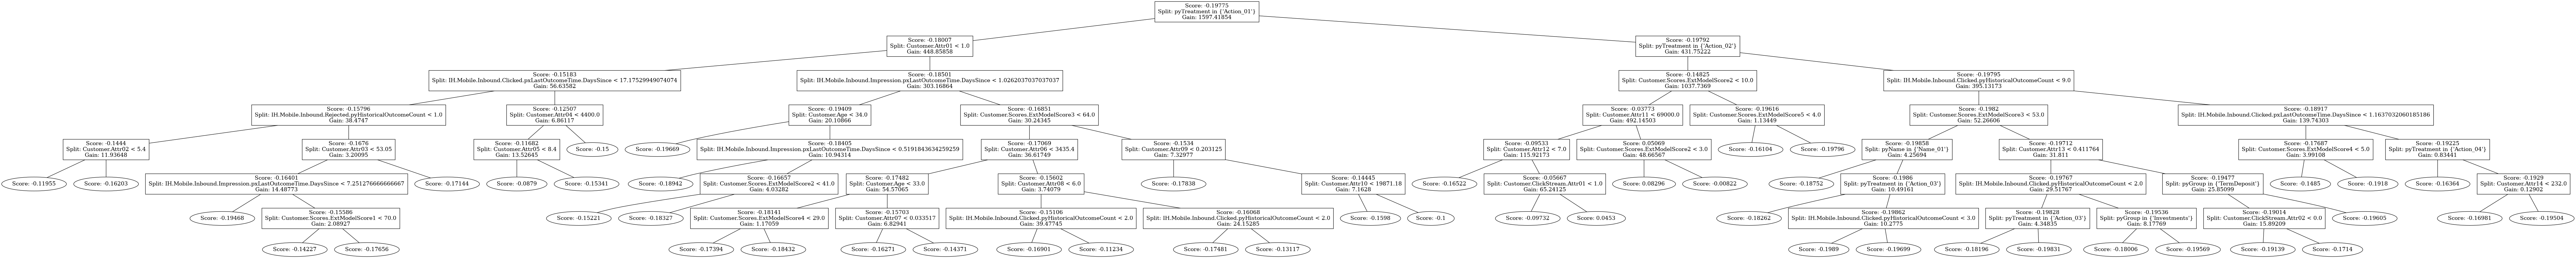

In [5]:
# Visualise tree 0 (requires pydot + graphviz)
AGBModel.plot.tree(0)


## 2. The Ensemble: How Trees Build on Each Other

AGB is an **additive model**.  Each new tree is trained on the *residuals* of
all previous trees — it corrects whatever the ensemble got wrong so far.

### The Scoring Formula

For a customer $x$, the raw log-odds score is the sum of all leaf scores:

$$
s = \sum_{k=1}^{K} \text{score}_k(x)
$$

where $\text{score}_k(x)$ is the leaf score of tree $k$ for input $x$.

The **propensity** (predicted probability of a positive outcome) is:

$$
p = \sigma(s) = \frac{1}{1 + e^{-s}}
$$

The leaf scores stored in the model JSON already incorporate the learning
rate ($\eta$) applied during training — there is no separate $\eta$ factor
at scoring time.

### Cold Start and Warm Start

**Cold start:** A new model starts with zero trees, so $s = 0$ and the
initial propensity is exactly $\sigma(0) = 0.5$:


In [6]:
from math import exp

# Cold-start propensity: no trees → score sum is 0
cold_start_propensity = 1 / (1 + exp(0))
print(f"Cold-start propensity: {cold_start_propensity}")  # exactly 0.5


Cold-start propensity: 0.5


**Warm start:** When a new treatment or action is introduced with similar
attributes to an existing one, the model immediately benefits from predictors
it has already learned.  The new treatment reuses splits built for similar
treatments, giving it an advantage over a blank-slate model.

### Per-Tree Statistics

The table below summarises each tree.  Early trees capture the strongest
signals (high gain, large root score magnitude).  Later trees make finer
corrections.


In [7]:
# Per-tree summary — drop the raw gains list for display
(
    GT(
        AGBModel.tree_stats
        .select("treeID", "score", "depth", "nsplits", "meangains")
        .rename({"treeID": "Tree", "score": "Root score", "depth": "Depth",
                 "nsplits": "Splits", "meangains": "Mean gain"})
        .head(10)
    )
    .tab_header(title="First 10 AGBModel — Summary")
    .fmt_number(columns=["Root score", "Mean gain"], decimals=4)
)


GT(_tbl_data=shape: (10, 5)
┌──────┬────────────┬───────┬────────┬────────────┐
│ Tree ┆ Root score ┆ Depth ┆ Splits ┆ Mean gain  │
│ ---  ┆ ---        ┆ ---   ┆ ---    ┆ ---        │
│ i64  ┆ f64        ┆ i64   ┆ i64    ┆ f64        │
╞══════╪════════════╪═══════╪════════╪════════════╡
│ 0    ┆ -0.19775   ┆ 7     ┆ 46     ┆ 123.225101 │
│ 1    ┆ -0.17984   ┆ 7     ┆ 76     ┆ 69.84757   │
│ 2    ┆ -0.16629   ┆ 7     ┆ 65     ┆ 66.428906  │
│ 3    ┆ -0.15566   ┆ 7     ┆ 49     ┆ 59.691001  │
│ 4    ┆ -0.14724   ┆ 7     ┆ 76     ┆ 34.537701  │
│ 5    ┆ -0.14024   ┆ 7     ┆ 58     ┆ 62.096661  │
│ 6    ┆ -0.13451   ┆ 7     ┆ 54     ┆ 68.546503  │
│ 7    ┆ -0.12972   ┆ 7     ┆ 51     ┆ 66.824975  │
│ 8    ┆ -0.12559   ┆ 7     ┆ 66     ┆ 59.63493   │
│ 9    ┆ -0.12182   ┆ 7     ┆ 73     ┆ 42.785277  │
└──────┴────────────┴───────┴────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x7fd4ecc30050>, _boxhead=Boxhead([ColInfo(var='Tree', type=<ColInfoTypeEnum.default: 1>, column_label='Tree', column_align='right', column_width=None), ColInfo(var='Root score', type=<ColInfoTypeEnum.default: 1>, column_label='Root score', column_align='right', column_width=None), ColInfo(var='Depth', type=<ColInfoTypeEnum.default: 1>, column_label='Depth', column_align='right', column_width=None), ColInfo(var='Splits', type=<ColInfoTypeEnum.default: 1>, column_label='Splits', column_align='right', column_width=None), ColInfo(var='Mean gain', type=<ColInfoTypeEnum.default: 1>, column_label='Mean gain', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd514bcc710>, _spanners=Spanners([]), _heading=Heading(title='First 10 AGBModel — Summary', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd4ed677b10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd5248b1cd0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fd504cba0d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fd4ecfa7010>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), tab

In [8]:
# Gain contribution per tree — early trees dominate
AGBModel.plot.gain_per_tree()


**Interpreting this chart:** A healthy ensemble shows a steep decline from left to right — the first 10–20 trees capture the bulk of the gain and later trees make progressively smaller corrections. A flat or rising tail suggests the model is still actively learning or that concept drift is continuously introducing new signal.

In [9]:
# Cumulative gain share — S-curve showing how quickly the ensemble saturates
AGBModel.plot.cumulative_gain_share()


**Interpreting this chart:** The dashed line marks where 50% of total gain has accumulated. **Good:** this crossover should fall well before the midpoint of the tree count — in this model around tree 38 out of 83 — confirming that a small core of early trees does most of the work and later trees add diminishing corrections. A late crossover (past the halfway point) indicates an unusually flat gain distribution.

### Training Stream

Because AGB trains online, we can reconstruct the timeline of tree additions
from the `sampleCount` stored in each tree's root node.  A new tree is added
after the ensemble has processed enough new responses to detect an improvement
opportunity.


In [10]:
# Total responses seen when each tree was added
AGBModel.plot.training_stream_timeline()


**Interpreting this chart:** Each point is a tree; the y-axis shows the total responses seen at the moment that tree was added. **Good:** a gently declining curve — the first tree was trained on the most data, and each subsequent tree refines a gradually changing stream. Steep steps indicate a burst of new data that triggered a new tree; a very flat curve suggests data was arriving slowly during that period.

In [11]:
# Response volume between consecutive tree additions
# Spikes indicate bursts of activity; long gaps indicate slow learning periods
AGBModel.plot.inter_tree_gaps()


**Interpreting this chart:** Each bar is the change in root `sampleCount` from the previous tree. Most values are negative (the ADWIN window shrinks between tree additions as old responses age out). **Good:** gaps cluster near zero with occasional small negative or positive spikes. Large positive spikes mark a flood of new training data that triggered a new tree; large negative spikes indicate significant pruning of stale observations.

In [12]:
# Gain decay — how much each tree contributes relative to its age
# x-axis: responses seen since that tree was added
AGBModel.plot.gain_decay_dual_lens()


**Interpreting this chart:** The steelblue trace shows gain by tree-index order; the orange dotted trace replots the same gain against *training age* (responses seen since that tree was added). **Good:** gain should be highest for the youngest trees (low training age, right side of the orange trace) and decay as trees age, confirming the model continuously renews itself. If the two traces look nearly identical in shape, the training rate has been roughly constant.

## 3. Scoring a Customer

To score a customer, the model traverses every tree from root to leaf,
collecting the leaf score for each tree, then applies the sigmoid.

Let's trace a concrete customer through the model.


In [13]:
# Build a concrete customer profile.
# For each predictor we pick the first threshold value seen in the model's splits
# (giving a real, self-consistent set of inputs), then override a few key fields.
x = {
    pred: (
        float(next(iter(AGBModel.all_values_per_split[pred])))
        if ptype == "numeric" and pred in AGBModel.all_values_per_split
        else next(iter(AGBModel.all_values_per_split.get(pred, {"Unknown"})))
    )
    for pred, ptype in AGBModel.predictors.items()
}
# Fix the treatment so tree 0 takes its left (positive) branch
x["pyTreatment"] = "Action_01"

# Show just the key context-key predictors
print("Key predictor values for this customer:")
for pred in ["pyTreatment", "pyName", "pyGroup"]:
    print(f"  {pred} = {x[pred]!r}")


Key predictor values for this customer:
  pyTreatment = 'Action_01'
  pyName = 'Name_08'
  pyGroup = 'PersonalLoan'


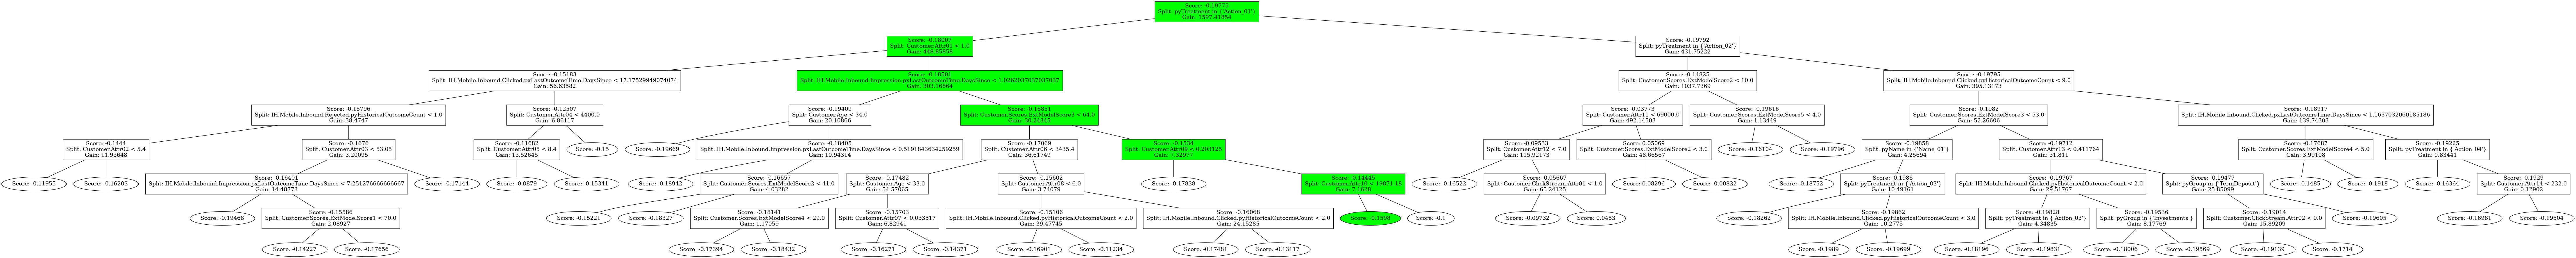

In [14]:
# Highlight the path taken through tree 0 (green nodes = visited)
AGBModel.plot.tree(0, highlighted=x)


In [15]:
# Per-tree leaf scores for this customer
visited = AGBModel.get_all_visited_nodes(x)
(
    GT(
        visited.select("treeID", "score")
        .rename({"treeID": "Tree", "score": "Leaf score"})
        .head(10)
    )
    .tab_header(title="First 10 Leaf Scores for Customer x")
    .fmt_number(columns=["Leaf score"], decimals=6)
)


GT(_tbl_data=shape: (10, 2)
┌──────┬────────────┐
│ Tree ┆ Leaf score │
│ ---  ┆ ---        │
│ i64  ┆ f64        │
╞══════╪════════════╡
│ 0    ┆ -0.1598    │
│ 1    ┆ -0.14078   │
│ 2    ┆ -0.15815   │
│ 3    ┆ -0.11657   │
│ 4    ┆ -0.14179   │
│ 5    ┆ -0.13229   │
│ 6    ┆ -0.13523   │
│ 7    ┆ -0.12947   │
│ 8    ┆ -0.12395   │
│ 9    ┆ -0.12246   │
└──────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x7fd4ecc303d0>, _boxhead=Boxhead([ColInfo(var='Tree', type=<ColInfoTypeEnum.default: 1>, column_label='Tree', column_align='right', column_width=None), ColInfo(var='Leaf score', type=<ColInfoTypeEnum.default: 1>, column_label='Leaf score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd4e417aa50>, _spanners=Spanners([]), _heading=Heading(title='First 10 Leaf Scores for Customer x', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd4e417b390>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd4ec13ff90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fd4e4107290>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fd4e417b5d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value=

In [16]:
# Manual verification: sum all leaf scores, apply sigmoid
raw_score = visited.get_column("score").sum()
propensity_manual = 1 / (1 + exp(-raw_score))
propensity_library = AGBModel.score(x)

print(f"Sum of leaf scores: {raw_score:.6f}")
print(f"Propensity (manual σ(s)): {propensity_manual:.6f}")
print(f"Propensity (AGBModel.score): {propensity_library:.6f}")
print(f"Match: {abs(propensity_manual - propensity_library) < 1e-10}")


Sum of leaf scores: -4.409290
Propensity (manual σ(s)): 0.012018
Propensity (AGBModel.score): 0.012018
Match: True


In [17]:
# Running propensity as each tree is added — shows convergence
AGBModel.plot.contribution_per_tree(x)


**Interpreting this chart:** Each bar is the incremental propensity change added by one tree for this specific customer. **Good:** the running total (visible in the cumulative trace) converges quickly — typically after 20–30 trees — and subsequent trees make only small adjustments. A propensity that is still oscillating late in the ensemble indicates a borderline customer where the model is genuinely uncertain.

## 4. Feature Importance: Which Predictors Drive the Model?

A predictor's importance is measured by its **total split gain** — the sum
of gain values at every split node that uses that predictor, across all trees.

> **Note on Prediction Studio:** In the Prediction Studio UI, feature
> importance is shown as a **0–100 score that sums to 100** across all
> active predictors.  The plots below use raw total gain (absolute scale),
> which is more useful for analysis but differs from the normalized UI value.
> Prediction Studio also offers **treatment-level feature importance**, showing
> which predictors matter most for each individual treatment.

Predictors are grouped into **Predictor Groups** that indicate the data source:

| Prefix | Predictor Group | Source |
|---|---|---|
| `py*` | Context Keys | Pega system context keys (e.g. `pyTreatment`, `pyGroup`) |
| `IH.*` | IH | Interaction History predictors |
| `Customer.*` | Customer | Customer attribute predictors |
| `<other>.*` | `<other>` | Any other dot-prefixed namespace |
| *(custom)* | External Models | External model scores — configure below |

### Predictors pre-processing

- **Symbolic predictors** use a custom encoding that allows for more granular
  bins than the classic Naïve Bayes algorithm.
- **Numeric predictors** are pre-processed using **percentile streaming**,
  which is robust against extreme outliers.

Both pre-processing steps contribute to AGB's higher predictive power compared
to the classic algorithm.


In [18]:
# Top split patterns by total gain
top_splits = (
    AGBModel.grouped_gains_per_split
    .with_columns(pl.col("gains").list.sum().alias("total_gain"))
    .sort("total_gain", descending=True)
    .head(10)
)
(
    GT(top_splits.select("split", "predictor", "n", "mean", "total_gain"))
    .tab_header(title="Top 10 Split Patterns by Total Gain")
    .cols_label(split="Split condition", predictor="Predictor", n="# occurrences",
                mean="Mean gain", total_gain="Total gain")
    .fmt_number(columns=["mean", "total_gain"], decimals=1)
)


GT(_tbl_data=shape: (10, 5)
┌────────────────────────────────┬────────────────────────────────┬─────┬────────────┬─────────────┐
│ split                          ┆ predictor                      ┆ n   ┆ mean       ┆ total_gain  │
│ ---                            ┆ ---                            ┆ --- ┆ ---        ┆ ---         │
│ str                            ┆ str                            ┆ u64 ┆ f64        ┆ f64         │
╞════════════════════════════════╪════════════════════════════════╪═════╪════════════╪═════════════╡
│ pyGroup in { Investments }     ┆ pyGroup                        ┆ 43  ┆ 669.645946 ┆ 28794.77568 │
│ IH.Mobile.Inbound.Clicked.pyHi ┆ IH.Mobile.Inbound.Clicked.pyHi ┆ 24  ┆ 546.234238 ┆ 13109.62172 │
│ …                              ┆ …                              ┆     ┆            ┆             │
│ IH.Mobile.Inbound.Clicked.pxLa ┆ IH.Mobile.Inbound.Clicked.pxLa ┆ 5   ┆ 1923.43389 ┆ 9617.16945  │
│ …                              ┆ …                              ┆     ┆            ┆             │
│ pyTreatment in { Action_01 }   ┆ pyTreatment                    ┆ 16  ┆ 601.021962 ┆ 9616.3514   │
│ pyGroup in { Savings,          ┆ pyGroup                        ┆ 21  ┆ 454.958444 ┆ 9554.12732  │
│ Personal…                      ┆                                ┆     ┆            ┆             │
│ IH.Mobile.Inbound.Clicked.pyHi ┆ IH.Mobile.Inbound.Clicked.pyHi ┆ 50  ┆ 178.549913 ┆ 8927.49563  │
│ …                              ┆ …                              ┆     ┆            ┆             │
│ pyTreatment in { Action_05,    ┆ pyTreatment                    ┆ 30  ┆ 263.197502 ┆ 7895.92506  │
│ Ac…                            ┆                                ┆     ┆            ┆             │
│ pyTreatment in { Action_05,    ┆ pyTreatment                    ┆ 43  ┆ 148.634358 ┆ 6391.2774   │
│ Ac…                            ┆                                ┆     ┆            ┆             │
│ IH.Mobile.Inbound.Clicked.pyHi ┆ IH.Mobile.Inbound.Clicked.pyHi ┆ 17  ┆ 348.265335 ┆ 5920.5107   │
│ …                              ┆ …                              ┆     ┆            ┆             │
│ pyGroup in { TermDeposit }     ┆ pyGroup                        ┆ 34  ┆ 162.797627 ┆ 5535.11932  │
└────────────────────────────────┴────────────────────────────────┴─────┴────────────┴─────────────┘, _body=<great_tables._gt_data.Body object at 0x7fd4b4a1e810>, _boxhead=Boxhead([ColInfo(var='split', type=<ColInfoTypeEnum.default: 1>, column_label='Split condition', column_align='left', column_width=None), ColInfo(var='predictor', type=<ColInfoTypeEnum.default: 1>, column_label='Predictor', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label='# occurrences', column_align='right', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean gain', column_align='right', column_width=None), ColInfo(var='total_gain', type=<ColInfoTypeEnum.default: 1>, column_label='Total gain', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd4e4bdd7d0>, _spanners=Spanners([]), _heading=Heading(title='Top 10 Split Patterns by Total Gain', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd514cafbd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd4e4b14c50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fd4ecf94950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fd4ed61cb90>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_ma

In [19]:
# Gain distribution per split condition for the top-5 predictors by total gain
top_preds = (
    AGBModel.grouped_gains_per_split
    .with_columns(pl.col("gains").list.sum().alias("total_gain"))
    .group_by("predictor")
    .agg(pl.col("total_gain").sum())
    .sort("total_gain", descending=True)
    .head(5)
    .get_column("predictor")
    .to_list()
)
AGBModel.plot.splits_per_variable(subset=set(top_preds));

In [20]:
# ---------------------------------------------------------------------------
# Custom Predictor Group assignment  (dataset-specific — edit as needed)
# ---------------------------------------------------------------------------
# External model scores are predictors that come from a separate model or
# scoring pipeline (e.g. propensity scores, risk scores).  They often share a
# common name prefix that distinguishes them from IH.* or Customer.* fields.
#
# Replace the `str.starts_with(...)` condition below with the actual prefix
# (or pattern) used in this dataset.  Examples:
#   pl.col("predictor").str.starts_with("ExtScore")
#   pl.col("predictor").is_in(["PropensityModel", "RiskScore"])
#
# Set EXTERNAL_SCORE_PREFIX = None to skip this grouping entirely.

from pdstools.adm.trees._plots import _PREDICTOR_GROUP_VALUE

EXTERNAL_SCORE_PREFIX = "Customer.Scores.ExtModelScore"

if EXTERNAL_SCORE_PREFIX is not None:
    AGBModel.plot.predictor_group_expr = (
        pl.when(pl.col("predictor").str.starts_with(EXTERNAL_SCORE_PREFIX))
        .then(pl.lit("External Models"))
        .otherwise(_PREDICTOR_GROUP_VALUE)
        .alias("Predictor Group")
    )
    # "External Models" is already in the default colormap; extend only if you
    # need additional custom groups:
    # AGBModel.plot.predictor_group_colormap = {
    #     **AGBModel.plot.predictor_group_colormap,
    #     "My Custom Group": "#AABBCC",
    # }


In [21]:
# Overall feature importance ranked by total gain
AGBModel.plot.feature_importance_by_gain()


**Interpreting this chart:** Predictors are sorted by their total split gain across all trees. **Good:** model-context fields (`pyGroup`, `pyIssue`, `pyTreatment`) dominating the top is expected and healthy — AGB uses a single model for all actions, so action identity is a powerful discriminator. Below those, interaction-history (`IH.*`) and customer-attribute predictors should contribute meaningfully. A single non-context predictor taking >50% of the gain warrants investigation for potential data leakage.

In [22]:
# Gain share by predictor group (IH.* vs Customer.* vs py* / Context Keys)
AGBModel.plot.gain_by_namespace()


**Interpreting this chart:** Each bar shows one predictor group's share of total split gain. **Good:** several groups each claiming 15–40% of the gain, indicating the model draws on diverse signals. A single group above 70–80% may indicate that other data sources are unavailable or that those predictors are inactive.


In [23]:
# Early learner vs late refiner — which predictors drive the first quarter of trees
# vs the last quarter?  Persistent predictors appear in both halves.
AGBModel.plot.early_vs_late_gain()


**Interpreting this chart:** Points above the diagonal are *late refiners* — their gain increases after many responses have arrived. Points below are *early specialists* — they drive the initial rapid learning. **Good:** model-context fields (`pyGroup`, `pyIssue`) typically land near the upper-left (early, dominant); behavioural predictors (`IH.*`) gradually strengthen over time and appear near or above the diagonal. Predictors clustered near the bottom-left contributed little in either phase and may be inactive.

In [24]:
# Feature role map:
#   x-axis = mean split depth (shallow = high-level router, deep = specialist refiner)
#   y-axis = fraction of trees where the predictor appears (coverage)
#   size   = total gain
AGBModel.plot.feature_role_map()


**Interpreting this chart:** The x-axis is mean split depth — shallow predictors (near 0) act as high-level routers at the top of every tree; deeper predictors fire only for specific sub-populations. The y-axis shows the fraction of trees the predictor appears in (coverage); bubble size is total gain. **Good:** model-context fields such as `pyGroup` should be shallow and widely covered; individual IH or customer predictors should be deeper and more selective. A large bubble with shallow depth and broad coverage is a powerful universal signal. A predictor with high coverage but a tiny bubble is splitting often without much gain — a candidate for review.

> **Single-case attribution (SHAP):** For individual propensity attribution —
> "why did this customer receive this propensity?" — Prediction Studio uses
> **Shapley values (SHAP)**.  The split-gain importance shown above is a
> model-level signal; SHAP provides the complementary per-customer view.


## 5. Model Health at a Glance

The `metrics` dictionary captures a comprehensive set of health indicators
computed from the model structure.  In production, many of these metrics are
exposed through PEGA_ADM05 telemetry and visible in Prediction Studio model
reports.

Key signals to watch:

| Metric | Healthy range | Signal |
|---|---|---|
| `score_decay_ratio` | < 1 | Converging model; > 1 may indicate instability |
| `top_predictor_gain_share` | < 0.5 | High value = over-reliance on one predictor |
| `predictor_gain_entropy` | High | Low entropy = gain concentrated in few predictors |
| `number_of_stump_trees` | Low | High = heavy pruning, possible concept drift |
| `mean_gain_last_half` < `mean_gain_first_half` | — | Expected; model converging |


In [25]:
# Build a readable metrics table
from IPython.display import HTML

descriptions = AGBModel.metric_descriptions()
metrics_df = pl.DataFrame({
    "Metric": list(AGBModel.metrics.keys()),
    "Value": [
        f"{v:.4f}" if isinstance(v, float) else str(v)
        for v in AGBModel.metrics.values()
    ],
    "Description": [descriptions.get(k, "") for k in AGBModel.metrics.keys()],
})
table_html = (
    GT(metrics_df)
    .tab_header(title="Model Health Metrics")
    .cols_width({"Metric": "25%", "Value": "15%", "Description": "60%"})
    .as_raw_html()
)
HTML(f'<div style="max-height:420px;overflow-y:auto">{table_html}</div>')

In [26]:
# Key "model not developing" diagnostics (SOP-ADM009)
# The split/tree ratio is computable from any model export.
# Saturation metrics require a datamart Modeldata blob — see note below.
m = AGBModel.metrics
total_splits = m["number_of_numeric_splits"] + m["number_of_symbolic_splits"]
ratio = total_splits / m["number_of_trees"]

print(f"Avg splits / tree:   {ratio:.1f}  ({'✓ OK' if ratio > 1 else '⚠ ALERT — model not developing'})")
print(f"Active predictors:   {m['total_number_of_active_predictors']}  "
      f"({'✓' if m['total_number_of_active_predictors'] >= 10 else '⚠ < 10 — may be too few to develop'})")
if "number_of_saturated_context_key_predictors" in m:
    print(f"Saturated context-key:     {m['number_of_saturated_context_key_predictors']}")
    print(f"Saturated symbolic:        {m['number_of_saturated_symbolic_predictors']}")
    print(f"Max context-key fill rate: {m['max_saturation_rate_on_context_key_predictors']:.0f} %")
else:
    print("Saturation metrics: not available for Prediction Studio exports.")
    print("Load via ADMDatamart.agb to see encoder fill rates.")


Avg splits / tree:   67.5  (✓ OK)
Active predictors:   194  (✓)
Saturation metrics: not available for Prediction Studio exports.
Load via ADMDatamart.agb to see encoder fill rates.


**Interpreting this output:** Avg splits/tree is the primary "not developing" signal — at or below 1 means most trees are stumps and the model is not learning structure from the data despite receiving responses.  If saturation metrics are available, check them first: a predictor whose encoder table is full cannot contribute new splits regardless of data volume, which explains why gain flatlines even as response counts climb.

In [27]:
# Splits by predictor type over the ensemble — symbolic vs numeric usage
AGBModel.plot.splits_per_variable_type()


**Interpreting this chart:** The Absolute view shows raw split counts per predictor type across trees; click **Relative** to compare proportional mix. A **healthy** model shows a stable percentage mix throughout the ensemble — a sudden shift late in training (e.g. symbolic splits spiking) can indicate a new data source becoming active or an imbalance in predictor coverage.

## 6. Model AUC and Calibration

After each new response, AGB applies a final calibration layer: the ensemble's raw log-odds score $s$ is passed through a **PAVA-calibrated propensity mapping** — the same Isotonic Regression (Pool Adjacent Violators) step used by the classic Naïve Bayes algorithm. The resulting propensity is the predicted probability exposed to the Next-Best-Action engine.

### Validated AUC: test-then-train

The model's AUC is a **validated** metric, not a training-set score. AGB uses **test-then-train**:

1. The incoming response is **first scored** by the current ensemble (producing a propensity via PAVA).
2. The predicted outcome is compared to the actual outcome, and the validated result contributes to the running AUC.
3. **Then** the model weights are updated.

This order ensures the AUC always reflects predictions made on data the model had not yet seen — it is a live, unbiased performance estimate.

### Pooled vs weighted-average AUC

**Pooled AUC** mixes prediction scores and outcomes from multiple actions into one combined ROC calculation. As the whitepaper shows, this number is structurally inflated by cross-action base-rate separation, so a high pooled AUC can coexist with weak per-action models.

**Weighted-average AUC** is the response-count weighted average of per-action AUC values. This is the honest, actionable portfolio metric because it answers the operational question that matters in NBA: does each action model rank likely responders above likely non-responders within its own action?

In practice, report weighted-average AUC as the primary portfolio measure and treat pooled AUC only as a descriptive aggregate, not as evidence of model quality.

### AGB vs Naïve Bayes: calibration observability

| Aspect | Naïve Bayes | AGB |
|---|---|---|
| PAVA bins exported? | ✅ Yes — visible in ADM datamart | ❌ No — internal to engine |
| AUC derivable from bins? | ✅ `auc_from_bincounts()` | ❌ Only the pre-computed scalar |
| AUC is validated? | ✅ test-then-train | ✅ test-then-train |

> **Note:** PAVA bins are not exported for AGB models — only the pre-computed AUC scalar. For Naïve Bayes models, `auc_from_bincounts()` can re-derive AUC from the exported bins.